<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/ReinforcementLearningAndDecisionMaking/ReinforcementLearningAndDecisionMaking/Q_Learning_For_Trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install stable-baselines3

In [14]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv

In [15]:
# --- 1. CONFIGURATION ---
TICKER = "NVDA"
START_DATE = "2015-01-01"
END_DATE = "2024-01-01"
WINDOW_SIZE = 30        # Agent looks back 30 days
INITIAL_BALANCE = 10000
TRANSACTION_FEE = 0.001 # 0.1%

In [16]:
# --- 2. DATA WITH INDICATORS ---
def get_data(ticker):
    df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)

    # Flatten MultiIndex if necessary
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Calculate Technical Indicators
    # 1. RSI (Relative Strength Index)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # 2. MACD (Moving Average Convergence Divergence)
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # 3. Volatility (ATR-ish: Rolling Std Dev)
    df['Vol'] = df['Close'].pct_change().rolling(20).std()

    # Drop NaNs created by indicators
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Select features: Open, High, Low, Close, Volume, RSI, MACD, Signal, Vol
    return df[['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'Signal', 'Vol']]

In [17]:
# Load Data
full_df = get_data(TICKER)
train_size = int(len(full_df) * 0.8)
train_df = full_df.iloc[:train_size].reset_index(drop=True)
test_df = full_df.iloc[train_size:].reset_index(drop=True)

print(f"🔥 Data Loaded: {len(train_df)} Training Days | {len(test_df)} Test Days")
print(f"Features: {list(train_df.columns)}")

🔥 Data Loaded: 1795 Training Days | 449 Test Days
Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'MACD', 'Signal', 'Vol']


/tmp/ipython-input-970556430.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
class AdvancedTradingEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, df):
        super(AdvancedTradingEnv, self).__init__()
        self.df = df
        self.max_steps = len(self.df) - 1
        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(WINDOW_SIZE, 9), dtype=np.float32
        )
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = WINDOW_SIZE
        self.balance = INITIAL_BALANCE
        self.shares_held = 0
        self.net_worth = INITIAL_BALANCE
        self.max_net_worth = INITIAL_BALANCE

        # LOGGING (New)
        self.trades = [] # Log: {step, type, price, shares, value}
        self.history = [] # Log: {step, net_worth}

        return self._get_observation(), {}

    def _get_observation(self):
        # (Same normalization logic as before - keep it identical)
        frame = self.df.iloc[self.current_step - WINDOW_SIZE : self.current_step].values
        obs = frame.copy()
        base_price = float(obs[0, 3])
        obs[:, :4] = obs[:, :4] / base_price
        vol_base = np.mean(obs[:, 4]) + 1
        obs[:, 4] = obs[:, 4] / vol_base
        obs[:, 5] = obs[:, 5] / 100.0
        obs[:, 6] = obs[:, 6] / base_price
        obs[:, 7] = obs[:, 7] / base_price
        return obs.astype(np.float32)

    def step(self, action):
        current_price = float(self.df.loc[self.current_step, 'Close'])
        timestamp = self.df.index[self.current_step]

        # EXECUTION LOGIC
        if action == 1: # BUY
            if self.balance > 0:
                cost = self.balance * (1 - TRANSACTION_FEE)
                shares = cost / current_price
                self.shares_held += shares
                self.balance = 0

                # Log Trade
                self.trades.append({
                    'Date': timestamp, 'Type': 'BUY',
                    'Price': current_price, 'Shares': shares, 'Value': cost
                })

        elif action == 2: # SELL
            if self.shares_held > 0:
                revenue = self.shares_held * current_price * (1 - TRANSACTION_FEE)

                # Log Trade
                self.trades.append({
                    'Date': timestamp, 'Type': 'SELL',
                    'Price': current_price, 'Shares': self.shares_held, 'Value': revenue
                })

                self.balance += revenue
                self.shares_held = 0

        self.current_step += 1
        current_net_worth = self.balance + (self.shares_held * current_price)

        # REWARD (Same Intensity)
        prev_net_worth = self.net_worth
        reward = np.log(current_net_worth / prev_net_worth) if prev_net_worth > 0 else 0
        reward = reward * 100

        self.net_worth = current_net_worth
        self.max_net_worth = max(self.max_net_worth, self.net_worth)
        self.history.append({'Date': timestamp, 'Net_Worth': self.net_worth})

        terminated = self.net_worth < INITIAL_BALANCE * 0.5
        truncated = self.current_step >= len(self.df) - 1

        return self._get_observation(), reward, terminated, truncated, {'net_worth': self.net_worth}

In [19]:
# Setup Environment
env = DummyVecEnv([lambda: AdvancedTradingEnv(train_df)])

print("🧠 Initializing Deep Q-Network...")

model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=0.0001,     # Slower learning rate for stability
    buffer_size=100000,       # Large memory
    learning_starts=1000,     # Observe 1000 steps before training
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.2, # Explore 20% of the time initially
    target_update_interval=500
)

print("🏋️‍♂️ Training Started (Target: 100,000 steps)...")
model.learn(total_timesteps=100000)
print("✅ Training Complete.")

🧠 Initializing Deep Q-Network...
Using cuda device
🏋️‍♂️ Training Started (Target: 100,000 steps)...
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.665    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 521      |
|    time_elapsed     | 13       |
|    total_timesteps  | 7056     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.879    |
|    n_updates        | 1513     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.33     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 615      |
|    time_elapsed     | 22       |
|    total_timesteps  | 14112    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.546    |
|    n_updates        | 3277     |
------------------------

In [20]:
# --- BACKTESTING ---
test_env = AdvancedTradingEnv(test_df)
obs, _ = test_env.reset()
done = False
ai_net_worth = []

print("🧪 Running Backtest on Unseen Data...")

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated
    ai_net_worth.append(info['net_worth'])

🧪 Running Backtest on Unseen Data...


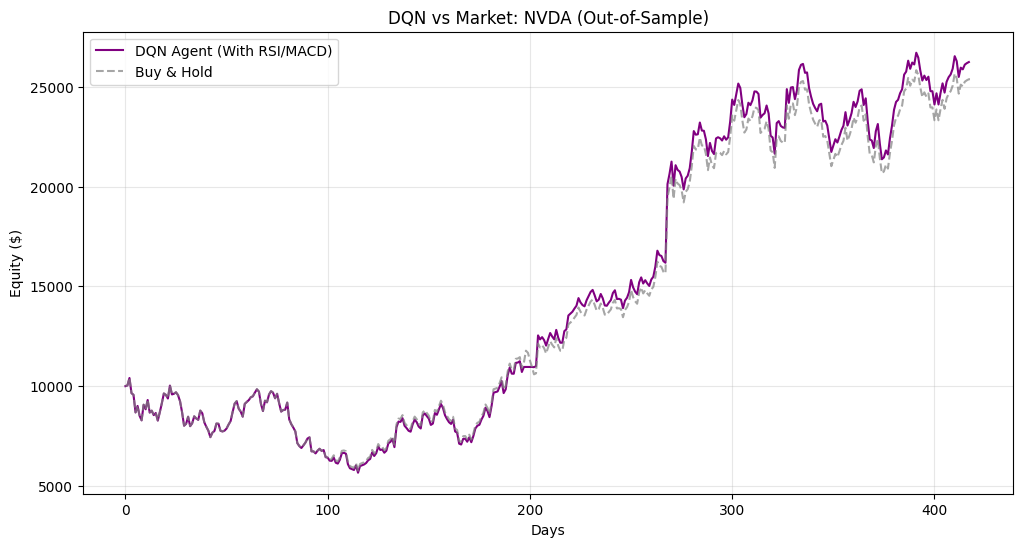

In [21]:
# --- BENCHMARK ---
initial_price = test_df.iloc[WINDOW_SIZE]['Close']
bench_equity = [INITIAL_BALANCE * (p / initial_price) for p in test_df['Close'][WINDOW_SIZE:]]

# --- PLOTTING ---
plt.figure(figsize=(12, 6))
plt.plot(ai_net_worth, label='DQN Agent (With RSI/MACD)', color='purple')
plt.plot(bench_equity, label='Buy & Hold', color='gray', linestyle='--', alpha=0.7)
plt.title(f"DQN vs Market: {TICKER} (Out-of-Sample)")
plt.ylabel("Equity ($)")
plt.xlabel("Days")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# --- SCOREBOARD ---
print(f"🟣 AI Final:    ${ai_net_worth[-1]:,.2f}")
print(f"⚪ Bench Final: ${bench_equity[-1]:,.2f}")

🟣 AI Final:    $26,245.34
⚪ Bench Final: $25,383.63


In [23]:
from scipy import stats

def generate_tear_sheet(env, benchmark_series):
    """
    Generates a professional performance report.
    Args:
        env: The Gym environment instance (must have run a backtest).
        benchmark_series: Pandas Series of Benchmark Prices (aligned dates).
    """
    # 1. Prepare Data
    equity_df = pd.DataFrame(env.history).set_index('Date')
    equity_curve = equity_df['Net_Worth']

    # Align dates with benchmark (Intersection)
    aligned_data = pd.DataFrame({
        'Strategy': equity_curve,
        'Benchmark': benchmark_series
    }).dropna()

    # Calculate Returns
    returns = aligned_data.pct_change().dropna()
    strat_ret = returns['Strategy']
    bench_ret = returns['Benchmark']

    # 2. TRADE ANALYSIS (Win Rate & Profit Factor)
    trades = pd.DataFrame(env.trades)
    win_rate = 0.0
    profit_factor = 0.0
    avg_win_loss = 0.0
    num_trades = 0

    if not trades.empty:
        # Reconstruct PnL per Round Trip (Simplified: Buy -> Sell)
        # Assumes the bot alternates Buy/Sell. If it buys twice, we average entry.
        sells = trades[trades['Type'] == 'SELL']
        buys = trades[trades['Type'] == 'BUY']

        if len(sells) > 0 and len(buys) > 0:
            # Match trades (FIFO logic simplified for metrics)
            n = min(len(sells), len(buys))
            pnl_series = (sells['Value'].values[:n] - buys['Value'].values[:n])

            wins = pnl_series[pnl_series > 0]
            losses = pnl_series[pnl_series <= 0]

            num_trades = len(pnl_series)
            win_rate = len(wins) / num_trades if num_trades > 0 else 0

            gross_profit = wins.sum()
            gross_loss = abs(losses.sum())
            profit_factor = gross_profit / gross_loss if gross_loss > 0 else float('inf')

            avg_win = wins.mean() if len(wins) > 0 else 0
            avg_loss = abs(losses.mean()) if len(losses) > 0 else 0
            avg_win_loss = avg_win / avg_loss if avg_loss > 0 else 0

    # 3. STATISTICAL METRICS
    risk_free_rate = 0.0

    # CAGR
    days = len(aligned_data)
    total_ret_strat = (aligned_data['Strategy'].iloc[-1] / aligned_data['Strategy'].iloc[0]) - 1
    cagr_strat = (1 + total_ret_strat) ** (252/days) - 1

    # Volatility
    ann_vol = strat_ret.std() * np.sqrt(252)

    # Sharpe & Sortino
    sharpe = (strat_ret.mean() - risk_free_rate) / strat_ret.std() * np.sqrt(252)
    downside_ret = strat_ret[strat_ret < 0]
    sortino = (strat_ret.mean() - risk_free_rate) / downside_ret.std() * np.sqrt(252)

    # Max Drawdown
    cum_ret = (1 + strat_ret).cumprod()
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()
    calmar = cagr_strat / abs(max_dd) if max_dd != 0 else 0

    # Alpha & Beta (Regression)
    slope, intercept, r_value, p_value, std_err = stats.linregress(bench_ret, strat_ret)
    beta = slope
    alpha = intercept * 252 # Annualized

    # Information Ratio (Active Return / Tracking Error)
    active_ret = strat_ret - bench_ret
    tracking_error = active_ret.std() * np.sqrt(252)
    info_ratio = (active_ret.mean() * 252) / tracking_error if tracking_error > 0 else 0

    # 4. EXPOSURE TIME
    # Simple proxy: How many days did we have a position?
    # In this env, if Shares > 0 we are exposed.
    # Note: We'd need to log this daily. We can infer from flat returns = cash?
    # Let's use correlation as a proxy for "Market Engagement" or just skip precise exposure for now.

    # --- REPORT GENERATION ---
    print("\n" + "="*40)
    print(f"📊 STRATEGY PERFORMANCE REPORT")
    print("="*40)
    print(f"TRADING STATS")
    print(f"----------------------------------------")
    print(f"Total Trades:      {num_trades}")
    print(f"Win Rate:          {win_rate*100:.1f}%")
    print(f"Profit Factor:     {profit_factor:.2f}")
    print(f"Avg Win/Loss:      {avg_win_loss:.2f}")

    print(f"\nRETURN METRICS")
    print(f"----------------------------------------")
    print(f"Total Return:      {total_ret_strat*100:.1f}%")
    print(f"CAGR (Ann):        {cagr_strat*100:.1f}%")
    print(f"Benchmark CAGR:    {((aligned_data['Benchmark'].iloc[-1]/aligned_data['Benchmark'].iloc[0])**(252/days)-1)*100:.1f}%")
    print(f"Alpha (Ann):       {alpha*100:.2f}%  (Skill)")
    print(f"Beta:              {beta:.2f}    (Market Sensitivity)")

    print(f"\nRISK METRICS")
    print(f"----------------------------------------")
    print(f"Volatility (Ann):  {ann_vol*100:.1f}%")
    print(f"Sharpe Ratio:      {sharpe:.2f}  (Reward/Risk)")
    print(f"Sortino Ratio:     {sortino:.2f} (Reward/Downside)")
    print(f"Max Drawdown:      {max_dd*100:.1f}%")
    print(f"Calmar Ratio:      {calmar:.2f}  (Return/Drawdown)")
    print(f"Information Ratio: {info_ratio:.2f} (Consistency vs Bench)")
    print("="*40)

    return equity_curve, drawdown


📊 STRATEGY PERFORMANCE REPORT
TRADING STATS
----------------------------------------
Total Trades:      2
Win Rate:          50.0%
Profit Factor:     1.26
Avg Win/Loss:      1.26

RETURN METRICS
----------------------------------------
Total Return:      162.7%
CAGR (Ann):        79.0%
Benchmark CAGR:    75.3%
Alpha (Ann):       2.81%  (Skill)
Beta:              0.99    (Market Sensitivity)

RISK METRICS
----------------------------------------
Volatility (Ann):  54.1%
Sharpe Ratio:      1.34  (Reward/Risk)
Sortino Ratio:     2.29 (Reward/Downside)
Max Drawdown:      -45.7%
Calmar Ratio:      1.73  (Return/Drawdown)
Information Ratio: 0.31 (Consistency vs Bench)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


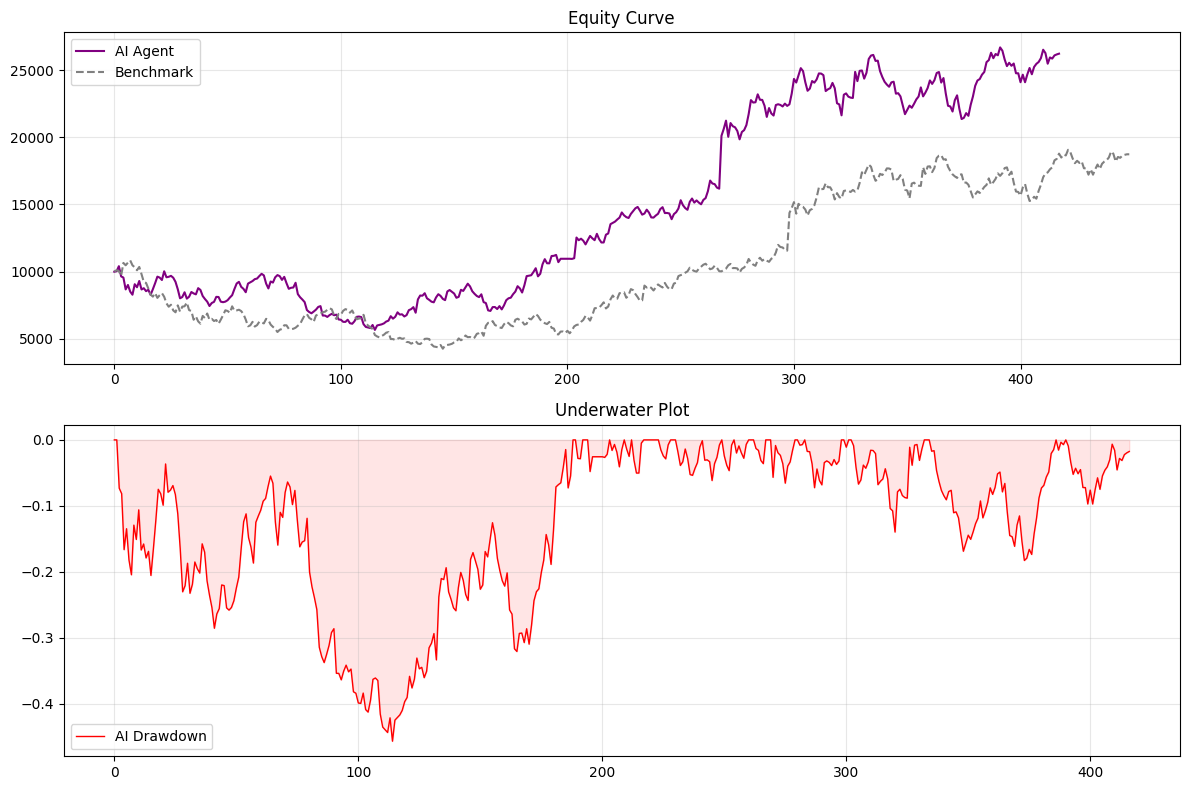

In [24]:
# Assuming you have run the backtest loop and populated 'test_env'

# 1. Create Benchmark Series (Aligned with Test Data)
# We need the actual prices corresponding to the test environment dates
benchmark_prices = test_df.set_index(pd.to_datetime(test_df.index))['Close'] # Adjust if Index is not datetime
# If index is integer 0..N, we might need original dates.
# For now, let's assume test_df has the correct index or we just align by integer index.
if not isinstance(test_df.index, pd.DatetimeIndex):
    # If no dates, we just use integer alignment
    benchmark_prices = test_df['Close']

# 2. Generate Report
curve, dd = generate_tear_sheet(test_env, benchmark_prices)

# 3. Plotting
plt.figure(figsize=(12, 8))

# Top: Equity
plt.subplot(2, 1, 1)
plt.plot(curve.values, label='AI Agent', color='purple')
plt.plot(benchmark_prices.values / benchmark_prices.values[0] * INITIAL_BALANCE, label='Benchmark', color='gray', linestyle='--')
plt.title("Equity Curve")
plt.legend()
plt.grid(True, alpha=0.3)

# Bottom: Drawdown
plt.subplot(2, 1, 2)
plt.plot(dd.values, label='AI Drawdown', color='red', linewidth=1)
plt.fill_between(range(len(dd)), dd.values, 0, color='red', alpha=0.1)
plt.title("Underwater Plot")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()